In [1]:
library("iDINGO")
library("WGCNA")
library(edgeR)


Attaching package: ‘WGCNA’


The following object is masked from ‘package:stats’:

    cor


Loading required package: limma



In [6]:
path_nickole = "/media/caio/T7_Shield/PhD/BEPE/Backup/Tracy_Server_Backup/Nickole_Study_2024/data_preprocessing/"

df_dynamic = readRDS(paste(path_nickole,"df_dynamic_DC.RDS",sep=""))

miRNA_DGE = readRDS(paste(path_nickole,"DGEList_miRNA_filtered_norm.RDS",sep="")); 
piRNA_DGE = readRDS(paste(path_nickole,"DGEList_piRNA_filtered_norm.RDS",sep="")); 
tRNA_DGE  = readRDS(paste(path_nickole,"DGEList_tRNA_filtered_norm.RDS",sep=""));

dynamic_candidates  = readRDS(paste(path_nickole,"dynamic_cadidate_all_subjects_DC_DE.RDS",sep=""));

path_nickole2 = "/media/caio/T7_Shield/PhD/BEPE/Backup/Tracy_Server_Backup/Nickole_Study_2024/analysis/"
info_path = paste(path_nickole2,"data_for_modeling.csv",sep ="")
info_to_modeling = read.csv(info_path,
                            row.names = read.csv(info_path)[,1])[,-1]

In [7]:
dynamic_miRNA = dynamic_candidates$miRNA_DE[(dynamic_candidates$miRNA_DE$dynamic_count_DE >= 7),]$miRNA
dynamic_piRNA = dynamic_candidates$piRNA_DE[(dynamic_candidates$piRNA_DE$dynamic_count_DE >= 7),]$piRNA
dynamic_tRNA = dynamic_candidates$tRNA_DE[(dynamic_candidates$tRNA_DE$dynamic_count_DE >= 7),]$tRNA

# dynamic_miRNA = dynamic_candidates$miRNA[(dynamic_candidates$miRNA$dynamic_count >= 6),]$miRNA
# dynamic_piRNA = dynamic_candidates$piRNA[(dynamic_candidates$piRNA$dynamic_count >= 6),]$piRNA
# dynamic_tRNA = dynamic_candidates$tRNA[(dynamic_candidates$tRNA$dynamic_count >= 6),]$tRNA


sncRNA_DGE = rbind(miRNA_DGE[dynamic_miRNA,rownames(info_to_modeling)],
                   piRNA_DGE[dynamic_piRNA,rownames(info_to_modeling)],
                   tRNA_DGE[dynamic_tRNA,rownames(info_to_modeling)])

# sncRNA_DGE = rbind(miRNA_DGE[,rownames(info_to_modeling)],
#                    piRNA_DGE[,rownames(info_to_modeling)],
#                    tRNA_DGE[,rownames(info_to_modeling)])

In [9]:
increase_dynamic = read.csv(paste(path_nickole2,"mark_increase_dynamic.csv",sep=""))[,-1]
stability_low_dynamic = read.csv(paste(path_nickole2,"mark_stability_low_dynamic.csv",sep=""))[,-1]
stability_moderate_dynamic = read.csv(paste(path_nickole2,"mark_stability_moderate_dynamic.csv",sep=""))[,-1]

In [10]:
increase_dynamic$Sample_2m = c("006-9","007-4","023-5","025-4","042-9","055-8",
                               "084-9","085-8","104-5","107-8")

In [11]:
increase_dynamic = increase_dynamic[increase_dynamic$Record_ID %in% info_to_modeling$Subject,]

In [12]:
stability_low_dynamic$Sample_2m = c("014-4","016-5","016-6","016-8","016-9","037-5","043-6",
                                       "068-5","068-6","068-7","068-8","072-4","072-5","072-7",
                                       "075-6","075-9","086-8","086-5","086-7","086-8","086-9",
                                       "112-7","121-4","121-9","121-6","121-7","121-8","121-9")

stability_moderate_dynamic$Sample_2m = c("007-7","007-8","018-5","018-7","019-5","021-4","023-8",
                                            "023-9","025-5","025-6","025-9","046-9","055-4","055-9",
                                            "074-7","074-8","074-9","080-4","088-5","088-8","088-9",
                                            "104-7","104-8","104-9","107-5")

In [13]:
stability_low_dynamic = stability_low_dynamic[stability_low_dynamic$Record_ID %in% info_to_modeling$Subject,]
stability_moderate_dynamic = stability_moderate_dynamic[stability_moderate_dynamic$Record_ID %in% info_to_modeling$Subject,]

### Filter and Voom
_1 = increase vs. stable_low

_2 = stable_moderate  vs. stable_low

In [14]:
delay2m_1   = c(stability_low_dynamic$Sample_2m,increase_dynamic$Sample_2m)
delay2m_2   = c(stability_low_dynamic$Sample_2m,stability_moderate_dynamic$Sample_2m)

In [15]:
info_1 = info_to_modeling[unique(delay2m_1),]
dynamic_1 = c(rep(1,length(unique(stability_low_dynamic$Sample_2m))),rep(2,length(unique(increase_dynamic$Sample_2m))))
info_1$dynamic_1 = dynamic_1

#rownames(info_1) = gsub("[.]1","",rownames(info_1))

In [16]:
info_2 = info_to_modeling[unique(delay2m_2),]
dynamic_2 = c(rep(1,length(unique(stability_low_dynamic$Sample_2m))),rep(2,length(unique(stability_moderate_dynamic$Sample_2m))))
info_2$dynamic_2 = dynamic_2

#rownames(info_2) = gsub("[.]1","",rownames(info_2))

In [20]:
# new design matrix
design_matrix_1 = ~ dynamic_1 + (1|Batch) + (1|Subject)
design_matrix_2 = ~ dynamic_2 + (1|Batch) + (1|Subject)

# as factor
info_1$Batch =  as.factor(info_1$Batch)
info_2$Batch =  as.factor(info_2$Batch)

info_1$Subject =  as.factor(info_1$Subject)
info_2$Subject =  as.factor(info_2$Subject)

info_1$dynamic_1 =  as.factor(info_1$dynamic_1)
info_2$dynamic_2 =  as.factor(info_2$dynamic_2)

In [21]:
voom_expr_1 = variancePartition::voomWithDreamWeights(sncRNA_DGE[,unique(delay2m_1)], 
                                                      formula = design_matrix_1, 
                                                      info_1, lib.size = info_1$sequence_count)

voom_expr_2 = variancePartition::voomWithDreamWeights(sncRNA_DGE[,unique(delay2m_2)], 
                                                      formula = design_matrix_2, 
                                                      info_2, lib.size = info_2$sequence_count)

Memory usage to store result: >587.3 Kb

Dividing work into 9 chunks...


Total:2 s

Memory usage to store result: >784.5 Kb

Dividing work into 9 chunks...


Total:2 s



### WGCNA

In [28]:
# recommended setup in WGCNA documentation
options(stringsAsFactors = FALSE);
enableWGCNAThreads(nThreads = 12)

Allowing parallel execution with up to 12 working processes.


In [180]:
data_for_WGCNA_1 = t(voom_expr_1$E)
weights_for_WGCNA_1 = t(voom_expr_1$weights)

names_sncRNA_1 = gsub("hsa-","",colnames(data_for_WGCNA_1))
names_sncRNA_1 = gsub("Homo_sapiens_","",names_sncRNA_1)
colnames(data_for_WGCNA_1) = names_sncRNA_1
colnames(weights_for_WGCNA_1) = names_sncRNA_1

In [181]:
data_for_WGCNA_2 = t(voom_expr_2$E)
weights_for_WGCNA_2 = t(voom_expr_2$weights)

names_sncRNA = gsub("hsa-","",colnames(data_for_WGCNA_2))
names_sncRNA = gsub("Homo_sapiens_","",names_sncRNA)
colnames(data_for_WGCNA_2) = names_sncRNA
colnames(weights_for_WGCNA_2) = names_sncRNA

In [182]:
# Choose a set of soft-thresholding powers
powers = c(seq(4,10,by=1), seq(12,20, by=2));

In [183]:
# increase vs. stable_low
powerTables = list(data = pickSoftThreshold(data_for_WGCNA_1, powerVector=powers,verbose = F)[[2]]);
collectGarbage(); # power = 14; mean.k = 1.64

   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      4    0.326 -0.513          0.298   10.20     8.730  24.70
2      5    0.634 -0.649          0.656    7.28     5.700  20.00
3      6    0.612 -0.802          0.560    5.53     4.120  16.90
4      7    0.698 -0.921          0.723    4.39     3.090  14.70
5      8    0.652 -1.050          0.644    3.60     2.370  13.10
6      9    0.723 -1.080          0.709    3.03     1.940  11.80
7     10    0.756 -1.110          0.730    2.60     1.720  10.80
8     12    0.757 -1.020          0.731    2.02     1.260   9.34
9     14    0.803 -1.120          0.778    1.64     1.070   8.24
10    16    0.799 -1.160          0.792    1.39     0.993   7.39
11    18    0.795 -1.180          0.766    1.20     0.912   6.70
12    20    0.759 -1.140          0.707    1.06     0.873   6.12


In [184]:
# stable_moderate vs. stable_low
powerTables = list(data = pickSoftThreshold(data_for_WGCNA_2, powerVector=powers,verbose = F)[[2]]);
collectGarbage(); # power = 6; mean.k = 5.98

   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      4    0.583 -0.538         0.4640   10.60     9.990  26.30
2      5    0.747 -0.628         0.6750    7.73     7.010  21.40
3      6    0.831 -0.732         0.7890    5.98     4.800  18.30
4      7    0.856 -0.827         0.8250    4.81     3.620  16.10
5      8    0.875 -0.881         0.8500    3.99     2.740  14.40
6      9    0.791 -0.964         0.7490    3.38     2.130  13.10
7     10    0.811 -1.030         0.7620    2.92     1.810  12.10
8     12    0.732 -1.200         0.6620    2.28     1.340  10.50
9     14    0.790 -1.100         0.7350    1.86     1.030   9.32
10    16    0.695 -1.130         0.6080    1.56     1.000   8.41
11    18    0.145 -2.010        -0.0991    1.35     0.948   7.66
12    20    0.723 -1.110         0.6480    1.19     0.871   7.04


 Calculating module eigengenes block-wise from all genes


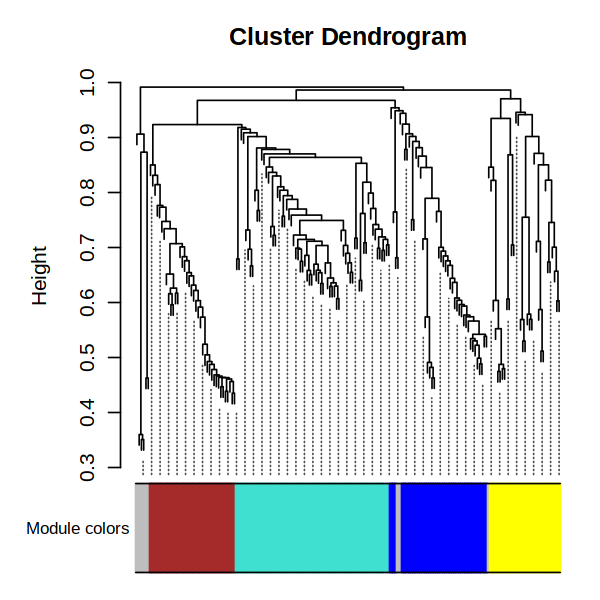

In [271]:
net = blockwiseModules(data_for_WGCNA_1, power = 9, networkType = "signed",
                        TOMType = "signed", minModuleSize = 19,
                        reassignThreshold = 0, mergeCutHeight = 0.25,
                        numericLabels = TRUE, pamRespectsDendro = FALSE,
                        verbose = 1)

# Convert labels to colors for plotting
mergedColors = labels2colors(net$colors)
names(mergedColors) = names(net$colors)
# Plot the dendrogram and the module colors underneath
options(repr.plot.width = 5, repr.plot.height = 5)
plotDendroAndColors(net$dendrograms[[1]], mergedColors[net$blockGenes[[1]]],
                    "Module colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)

# Define numbers of genes and samples
nGenes = ncol(data_for_WGCNA_1);
nSamples = nrow(data_for_WGCNA_1);
# Recalculate MEs with color labels
MEs0 = moduleEigengenes(data_for_WGCNA_1, mergedColors)$eigengenes
MEs_1 = orderMEs(MEs0)

# CAN'T USE cor() BECAUSE OF REPEATED MEASURES!
# moduleTraitCor = cor(MEs, as.factor(info_1$dynamic_1), use = "p");
# moduleTraitPvalue = corPvalueStudent(moduleTraitCor, nSamples);

datKME_1=signedKME(data_for_WGCNA_1, MEs_1, outputColumnName="MM_")

brown_1 = names(mergedColors[mergedColors == "brown"])
blue_1 = names(mergedColors[mergedColors == "blue"])
turquoise_1 = names(mergedColors[mergedColors == "turquoise"])
yellow_1 = names(mergedColors[mergedColors == "yellow"])

In [276]:
ACE_dynamic_1 = data.frame(Subject = info_1$Subject,
                           Batch = info_1$Batch,
                           Visit = info_1$Visit, 
                           PSS_delta_2m_prior = info_1$PSS_delta_prior_2m,
                           PSS_2m_prior = info_1$PSS_2m_prior,
                           ME1 = MEs_1$MEblue, ME2 = MEs_1$MEturquoise, 
                           ME3 = MEs_1$MEbrown, ME4 = MEs_1$MEyellow, Dynamic  = info_1$dynamic_1, 
                           ACE = info_1$ACE)
rownames(ACE_dynamic_1) = rownames(data_for_WGCNA_1)

ACE_dynamic_1$Dynamic = as.factor(ACE_dynamic_1$Dynamic)

ACE_dynamic_1$Blue_module_activity = ACE_dynamic_1$ME1
ACE_dynamic_1$Turquoise_module_activity = ACE_dynamic_1$ME2
ACE_dynamic_1$Brown_module_activity = ACE_dynamic_1$ME3
ACE_dynamic_1$Yellow_module_activity = ACE_dynamic_1$ME4

 Calculating module eigengenes block-wise from all genes


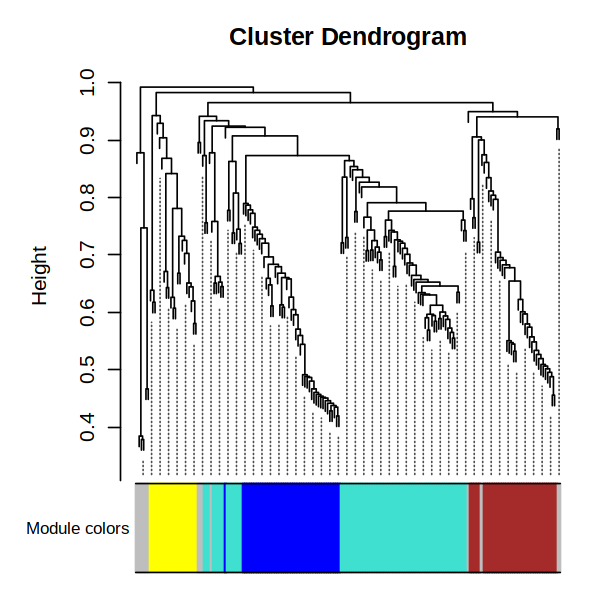

In [277]:
net = blockwiseModules(data_for_WGCNA_2, power = 8, networkType = "signed",
                        TOMType = "signed", minModuleSize = 19,
                        reassignThreshold = 0, mergeCutHeight = 0.25,
                        numericLabels = TRUE, pamRespectsDendro = FALSE,
                        verbose = 1)

# Convert labels to colors for plotting
mergedColors = labels2colors(net$colors)
names(mergedColors) = names(net$colors)
# Plot the dendrogram and the module colors underneath
options(repr.plot.width = 5, repr.plot.height = 5)
plotDendroAndColors(net$dendrograms[[1]], mergedColors[net$blockGenes[[1]]],
                    "Module colors",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)

# Define numbers of genes and samples
nGenes = ncol(data_for_WGCNA_2);
nSamples = nrow(data_for_WGCNA_2);
# Recalculate MEs with color labels
MEs0 = moduleEigengenes(data_for_WGCNA_2, mergedColors)$eigengenes
MEs_2 = orderMEs(MEs0)

# CAN'T USE cor() BECAUSE OF REPEATED MEASURES!
#moduleTraitCor = cor(MEs, as.factor(info_2$dynamic_2), use = "p");
#moduleTraitPvalue = corPvalueStudent(moduleTraitCor, nSamples);

datKME_2=signedKME(data_for_WGCNA_2, MEs, outputColumnName="MM_")

brown_2 = names(mergedColors[mergedColors == "brown"])
blue_2 = names(mergedColors[mergedColors == "blue"])
turquoise_2 = names(mergedColors[mergedColors == "turquoise"])
yellow_2 = names(mergedColors[mergedColors == "yellow"])

In [278]:
ACE_dynamic_2 = data.frame(Subject = info_2$Subject, 
                           Batch = info_2$Batch,
                           Visit = info_2$Visit, 
                           PSS_delta_2m_prior = info_2$PSS_delta_prior_2m,
                           PSS_2m_prior = info_2$PSS_2m_prior,
                           ME1 = MEs_2$MEblue, ME2 = MEs_2$MEturquoise, 
                           ME3 = MEs_2$MEbrown, ME4 = MEs_2$MEyellow, Dynamic = info_2$dynamic_2, 
                           ACE = info_2$ACE)
rownames(ACE_dynamic_2) = rownames(data_for_WGCNA_2)

ACE_dynamic_2$Dynamic = as.factor(ACE_dynamic_2$Dynamic)

ACE_dynamic_2$Blue_module_activity = ACE_dynamic_2$ME1
ACE_dynamic_2$Turquoise_module_activity = ACE_dynamic_2$ME2
ACE_dynamic_2$Brown_module_activity = ACE_dynamic_2$ME3
ACE_dynamic_2$Yellow_module_activity = ACE_dynamic_2$ME4

In [283]:
### MODULES INTERSECTION!! 

length(intersect(brown_1,blue_2))/length(brown_1)
length(intersect(blue_1,brown_2))/length(blue_1)
length(intersect(turquoise_1,turquoise_2))/length(turquoise_1)
length(intersect(yellow_1,yellow_2))/length(yellow_2)

[1] 1

[1] 0.8780488

[1] 0.8823529

[1] 0.9047619

In [264]:
representative_sncRNAs_1 = datKME_1 %>% dplyr::arrange(desc(MM_blue)) %>% 
dplyr::filter(MM_blue>0.7) %>% rownames()
representative_sncRNAs_2 = datKME_2 %>% dplyr::arrange(desc(MM_blue)) %>% 
dplyr::filter(MM_blue>0.7) %>% rownames()

In [265]:
length(representative_sncRNAs_1)
length(representative_sncRNAs_2)

[1] 26

[1] 27

In [268]:
length(intersect(representative_sncRNAs_1,representative_sncRNAs_2))

[1] 25

### Mixed models

In [ ]:
## lmer models
# add voom weights to models
# ICC for subjects

In [252]:
str(ACE_dynamic_1)

'data.frame':	36 obs. of  13 variables:
 $ Subject                  : Factor w/ 20 levels "50006","50007",..: 3 4 4 4 4 7 9 11 11 11 ...
 $ Batch                    : Factor w/ 6 levels "1","2","3","4",..: 1 1 1 1 1 2 1 5 5 5 ...
 $ Visit                    : int  4 5 6 8 9 5 6 5 6 7 ...
 $ PSS_delta_2m_prior       : int  4 1 -1 -1 0 3 4 -7 0 0 ...
 $ PSS_2m_prior             : int  7 7 7 6 7 3 6 10 7 3 ...
 $ ME1                      : num  -0.1479 -0.1417 -0.064 0.0518 0.0186 ...
 $ ME2                      : num  0.12417 -0.00281 0.24549 0.03663 0.22749 ...
 $ ME3                      : num  -0.1712 -0.2359 0.2032 -0.1619 0.0456 ...
 $ Dynamic                  : Factor w/ 2 levels "1","2": 1 1 1 1 1 1 1 1 1 1 ...
 $ ACE                      : int  1 4 4 4 4 3 1 1 1 1 ...
 $ Blue_module_activity     : num  -0.1479 -0.1417 -0.064 0.0518 0.0186 ...
 $ Turquoise_module_activity: num  0.12417 -0.00281 0.24549 0.03663 0.22749 ...
 $ Brown_module_activity    : num  -0.1712 -0.2359 0.2032 -

In [302]:
options(browser="firefox")
library(lme4)

In [331]:
batch_pss = split(ACE_dynamic_1,ACE_dynamic_1$Batch)
batch_pss$`1`$PSS_2m_prior
batch_pss$`2`$PSS_2m_prior
batch_pss$`3`$PSS_2m_prior
batch_pss$`4`$PSS_2m_prior
batch_pss$`5`$PSS_2m_prior
batch_pss$`6`$PSS_2m_prior

[1]  7  7  7  6  7  6 13  5

[1]  3  0  3  2  1 18 18

[1]  0  0  5 10 17

[1] 17 25

[1] 10  7  3  7 28 23

[1] 11  6  6  3  7  7 32 24

In [355]:
summary(model3)

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: 
Blue_module_activity ~ I(PSS_2m_prior^2) + I(ACE^2) + ACE:PSS_2m_prior +  
    (1 | Subject) + (1 | Batch)
   Data: ACE_dynamic_1

      AIC       BIC    logLik -2*log(L)  df.resid 
    -44.1     -33.0      29.1     -58.1        29 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.39517 -0.65198  0.06965  0.47702  1.63409 

Random effects:
 Groups   Name        Variance Std.Dev.
 Subject  (Intercept) 0.004334 0.06583 
 Batch    (Intercept) 0.016836 0.12976 
 Residual             0.005196 0.07208 
Number of obs: 36, groups:  Subject, 20; Batch, 6

Fixed effects:
                    Estimate Std. Error t value
(Intercept)       -0.0249204  0.0627811  -0.397
I(PSS_2m_prior^2)  0.0003284  0.0001729   1.900
I(ACE^2)           0.0021300  0.0037912   0.562
ACE:PSS_2m_prior  -0.0018640  0.0015132  -1.232

Correlation of Fixed Effects:
            (Intr) I(PSS_ I(ACE^
I(PSS_2_^2) -0.380              
I(ACE^2

In [383]:
null_model = lmer("Blue_module_activity ~ (1|Subject) + (1|Batch)",
                     ACE_dynamic_1, REML = FALSE)
model1 = lmer("Blue_module_activity ~ Dynamic  + (1|Subject) + (1|Batch)",
                     ACE_dynamic_1, REML = FALSE)
model2 = lmer("Blue_module_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                     ACE_dynamic_1, REML = FALSE)
model3 = lmer("Blue_module_activity ~ I(PSS_2m_prior^2) + I(ACE^2) + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                     ACE_dynamic_1, REML = FALSE)

model = lmer("Blue_module_activity ~ I(PSS_2m_prior^2) + ACE + (1|Subject) + (1|Batch)",
                     ACE_dynamic_1, REML = FALSE)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
null_model,4,-45.87396,-39.53989,26.93698,-53.87396,NA,NA,NA
model,6,-44.30788,-34.80677,28.15394,-56.30788,2.433924,2,0.2961285


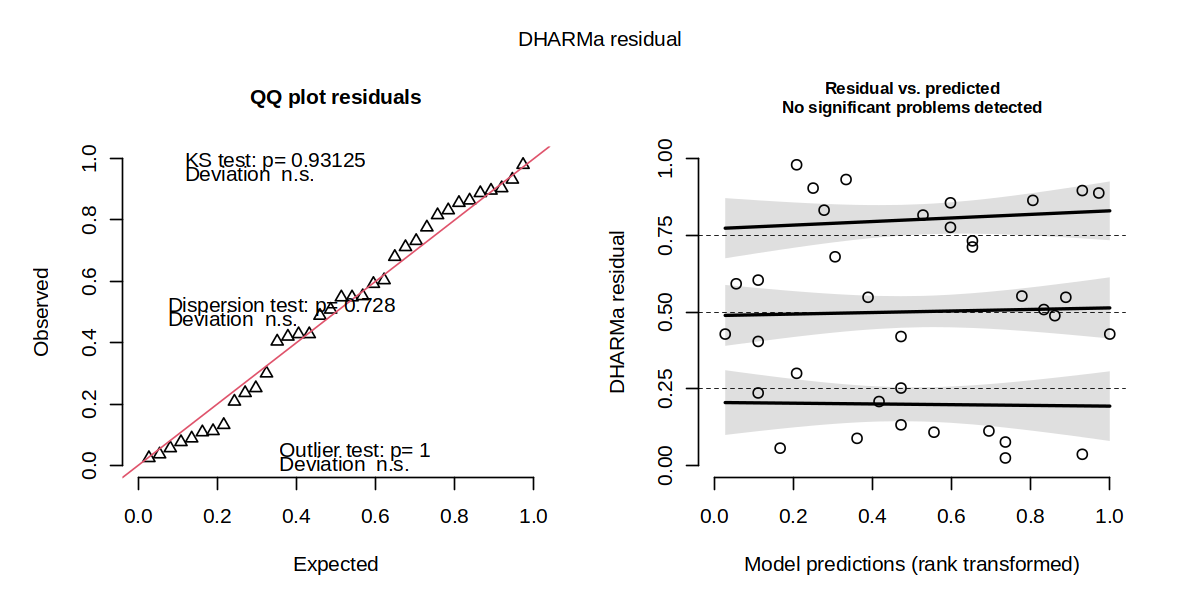

In [384]:
anova(null_model,model)

sjPlot::tab_model(null_model,model1,model2,model3, model,
                  show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

simulationOutput <- DHARMa::simulateResiduals(fittedModel = model3, plot = TRUE)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
model2,7,-43.99260,-32.90797,28.99630,-57.99260,NA,NA,NA
model3,7,-44.13157,-33.04693,29.06578,-58.13157,0.1389639,0,NA


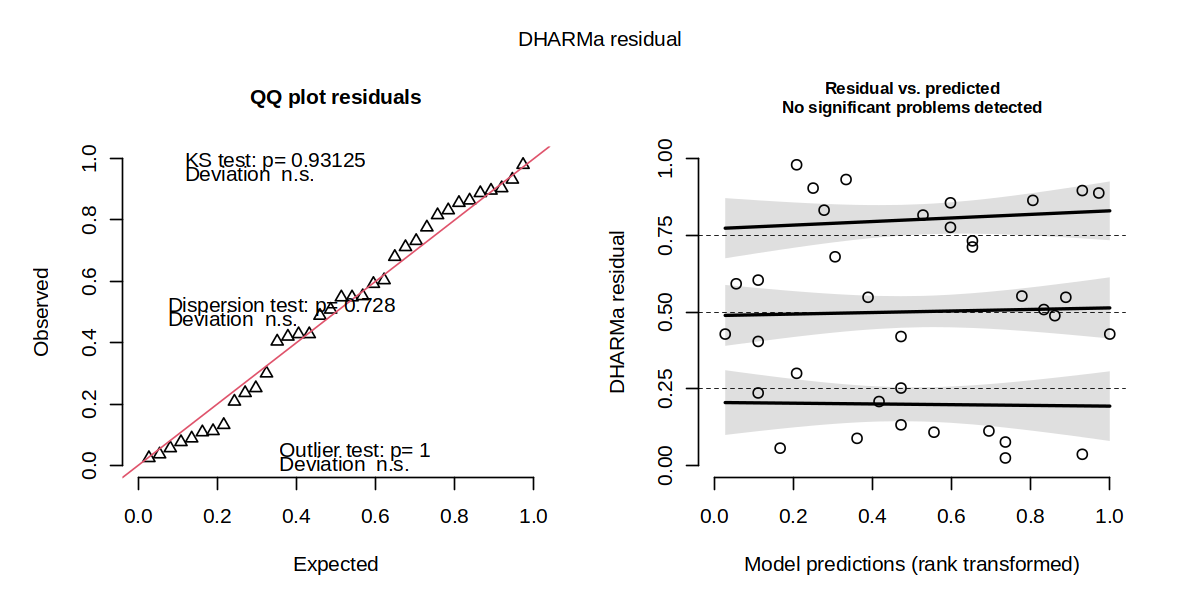

In [353]:
# not REML to use likelihood tests for model comparison
model1 = lmer("Blue_module_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject)",
                     ACE_dynamic_1, REML = FALSE)
model2 = lmer("Blue_module_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                     ACE_dynamic_1, REML = FALSE)
model3 = lmer("Blue_module_activity ~ I(PSS_2m_prior^2) + I(ACE^2) + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                     ACE_dynamic_1, REML = FALSE)

anova(model2,model3)

sjPlot::tab_model(model1,model2,model3,
                  show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

simulationOutput <- DHARMa::simulateResiduals(fittedModel = model3, plot = TRUE)

In [365]:
null_model = lmer("Brown_module_activity ~ (1|Subject) + (1|Batch)",
                     ACE_dynamic_2, REML = FALSE)
model1 = lmer("Brown_module_activity ~ Dynamic  + (1|Subject) + (1|Batch)",
                     ACE_dynamic_2, REML = FALSE)
model2 = lmer("Brown_module_activity ~ PSS_2m_prior + ACE + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                     ACE_dynamic_2, REML = FALSE)
model3 = lmer("Brown_module_activity ~ I(PSS_2m_prior^2) + I(ACE^2) + ACE:PSS_2m_prior + (1|Subject) + (1|Batch)",
                     ACE_dynamic_2, REML = FALSE)

model = lmer("Brown_module_activity ~ I(PSS_2m_prior^2) + (1|Subject) + (1|Batch)",
                     ACE_dynamic_2, REML = FALSE)

In [372]:
anova(null_model,model)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
null_model,4,-87.57970,-79.85240,47.78985,-95.57970,NA,NA,NA
model,5,-89.60736,-79.94823,49.80368,-99.60736,4.027658,1,0.04476004


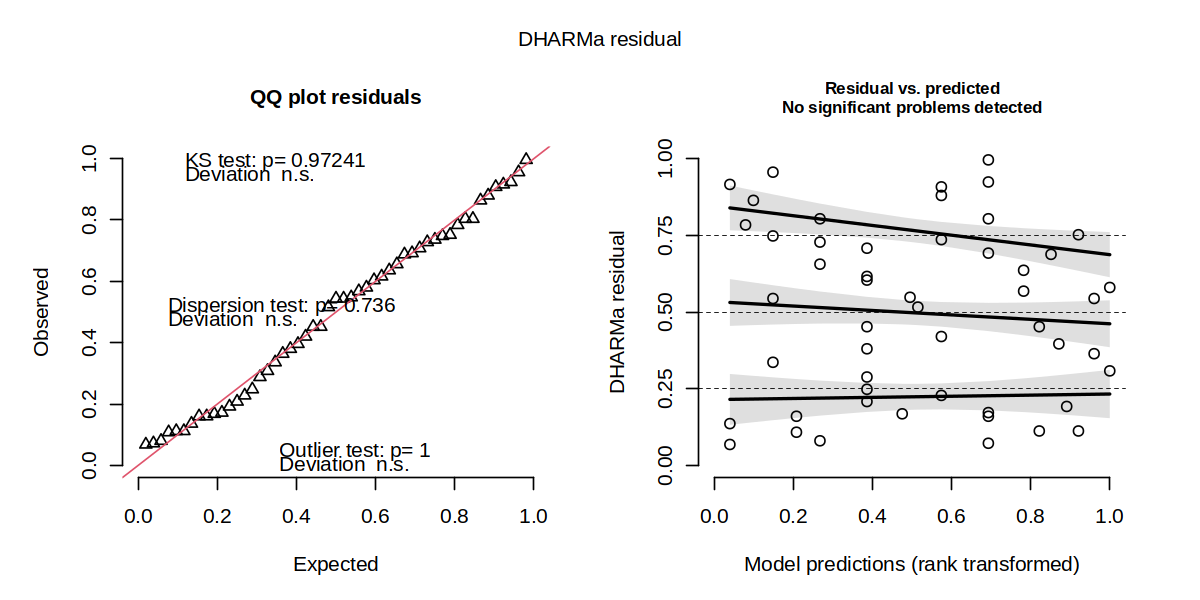

In [370]:
simulationOutput <- DHARMa::simulateResiduals(fittedModel = model, plot = TRUE)

In [371]:
sjPlot::tab_model(model1,model2,model3,model,
                  show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))

#simulationOutput <- DHARMa::simulateResiduals(fittedModel = model2, plot = TRUE)

Warning message in is.na(xlab):
“is.na() applied to non-(list or vector) of type 'expression'”


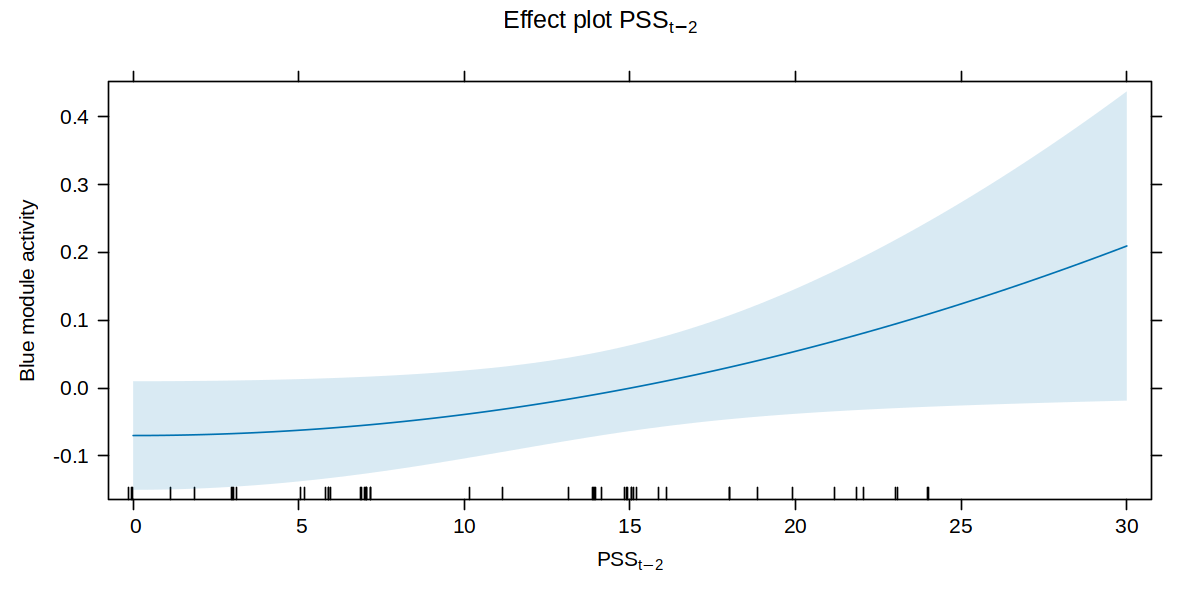

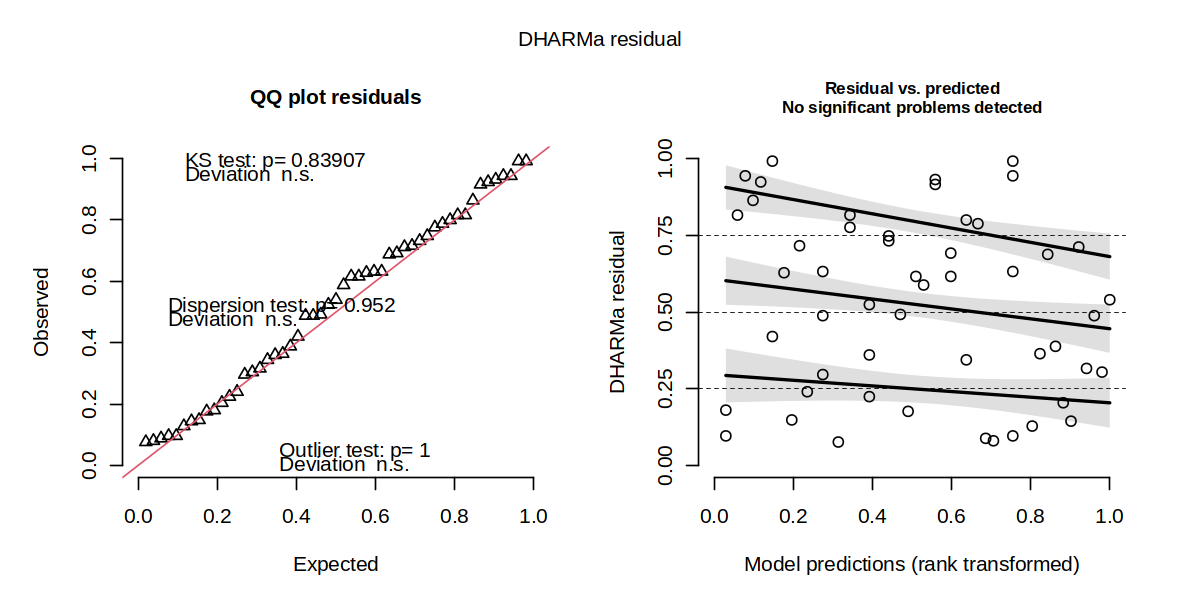

In [294]:
#options(browser="firefox")
library(lme4)

#datKME_2 %>% dplyr::arrange(desc(MM_blue)) %>% head()

model_ME2_abs = lmer("Brown_module_activity ~ I(PSS_2m_prior^2) + I(ACE^2) + (1|Subject)",
                     ACE_dynamic_2)
model_ME2_abs2 = lmer("Brown_module_activity ~ PSS_2m_prior + ACE +PSS_2m_prior:ACE + (1|Subject)",
                     ACE_dynamic_2)

plot(effects::Effect("PSS_2m_prior", model_ME2_abs,
                     xlevels=list(PSS_2m_prior=seq(0, 30, 1))), 
     main = expression("Effect plot PSS"[t-2]), 
     ylab = "Blue module activity",
     xlab = expression("PSS"[t-2]))

options(repr.plot.width = 10, repr.plot.height = 5)
simulationOutput <- DHARMa::simulateResiduals(fittedModel = model_ME2_abs, plot = TRUE)
# simulationOutput <- DHARMa::simulateResiduals(fittedModel = model_ME2_abs2, plot = TRUE)

sjPlot::tab_model(model_ME2_abs,
                  show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))
# sjPlot::tab_model(model_ME2_abs2,
#                   show.re.var = FALSE,digits = 5,p.threshold = c(0.05, 0.01, 0.001))